# Section 2: Hypothesis Testing
## 2.1 Load Cleaned Data
Load the cleaned project dataset produced in Section 1.

**Output.** Shows a preview of the analysis table used for all tests in this notebook.


In [1]:
from pathlib import Path
Path("plots_overleaf").mkdir(exist_ok=True)

import pandas as pd

df = pd.read_csv("merged_data.csv")
df.head()


,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


## 2.2 Weekday vs. Weekend Distribution Tests
Use city-specific Kolmogorov-Smirnov tests to compare weekday and weekend log-price distributions.

**Output.** Displays the city-level K-S summary table and saves the full city ECDF comparison plot.


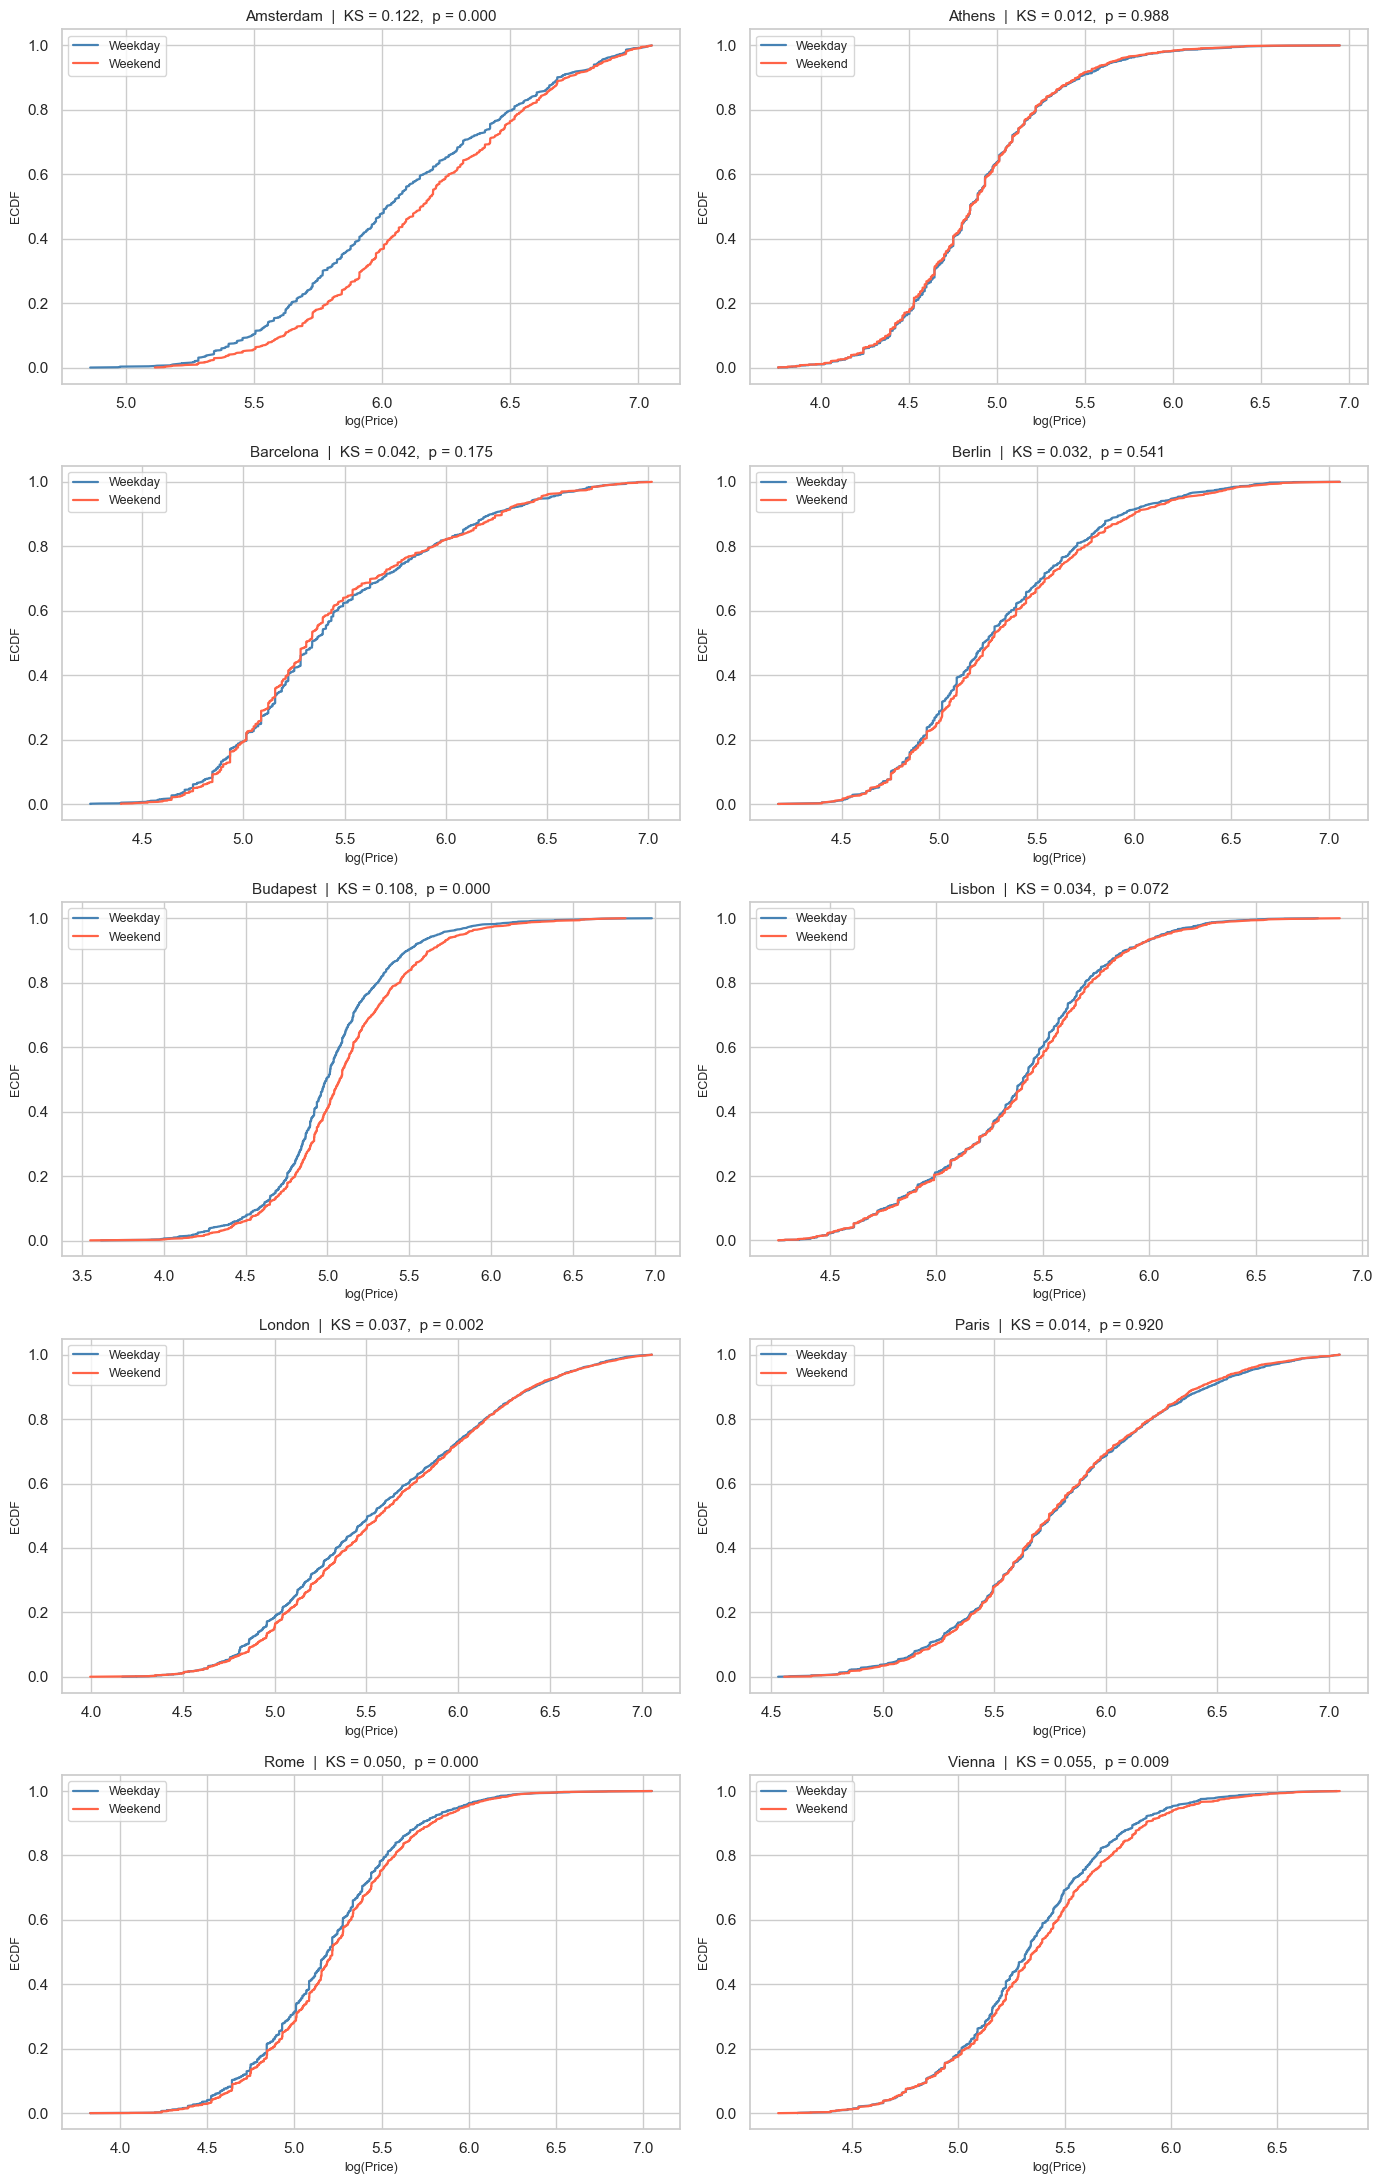

,KS Stat,p-value,n weekday,n weekend
City,,,,
Amsterdam,0.122,0.000,1043,901
Athens,0.012,0.988,2652,2627
Barcelona,0.042,0.175,1548,1264
Berlin,0.032,0.541,1277,1193
Budapest,0.108,0.000,2071,1945
Lisbon,0.034,0.072,2855,2905
London,0.037,0.002,4525,5268
Paris,0.014,0.920,3071,3500
Rome,0.050,0.000,4484,4526


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

CITY_NAMES = {
    1: 'Amsterdam', 2: 'Athens',    3: 'Barcelona', 4: 'Berlin',
    5: 'Budapest',  6: 'Lisbon',    7: 'London',    8: 'Paris',
    9: 'Rome',      10: 'Vienna'
}

ks_results = []

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for idx, (city_id, city_name) in enumerate(CITY_NAMES.items()):
    city_df   = df[df['city'] == city_name]
    weekday   = city_df[city_df['is_weekday'] == 1]['logSum'].values
    weekend   = city_df[city_df['is_weekday'] == 0]['logSum'].values

    ks_stat, p_value = stats.ks_2samp(weekday, weekend)
    ks_results.append({
        'City':     city_name,
        'KS Stat':  round(ks_stat, 3),
        'p-value':  round(p_value, 3),
        'n weekday': len(weekday),
        'n weekend': len(weekend),
    })

    # Plot ECDFs
    ax = axes[idx]
    for data, label, color in [(weekday, 'Weekday', 'steelblue'),
                                (weekend, 'Weekend', 'tomato')]:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, ecdf, label=label, color=color, linewidth=1.6)

    ax.set_title(f'{city_name}  |  KS = {ks_stat:.3f},  p = {p_value:.3f}', fontsize=11)
    ax.set_xlabel('log(Price)', fontsize=9)
    ax.set_ylabel('ECDF', fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots_overleaf/section2_PlotHypothesis1_weekdayWeekendKS.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
ks_df = pd.DataFrame(ks_results).set_index('City')
display(ks_df)


## 2.3 Amsterdam and Athens K-S Plot
Replot the weekday/weekend K-S ECDF comparison for Amsterdam and Athens only to make the city-specific distribution differences easier to read.

**Output.** Saves a focused Amsterdam/Athens ECDF comparison plot.


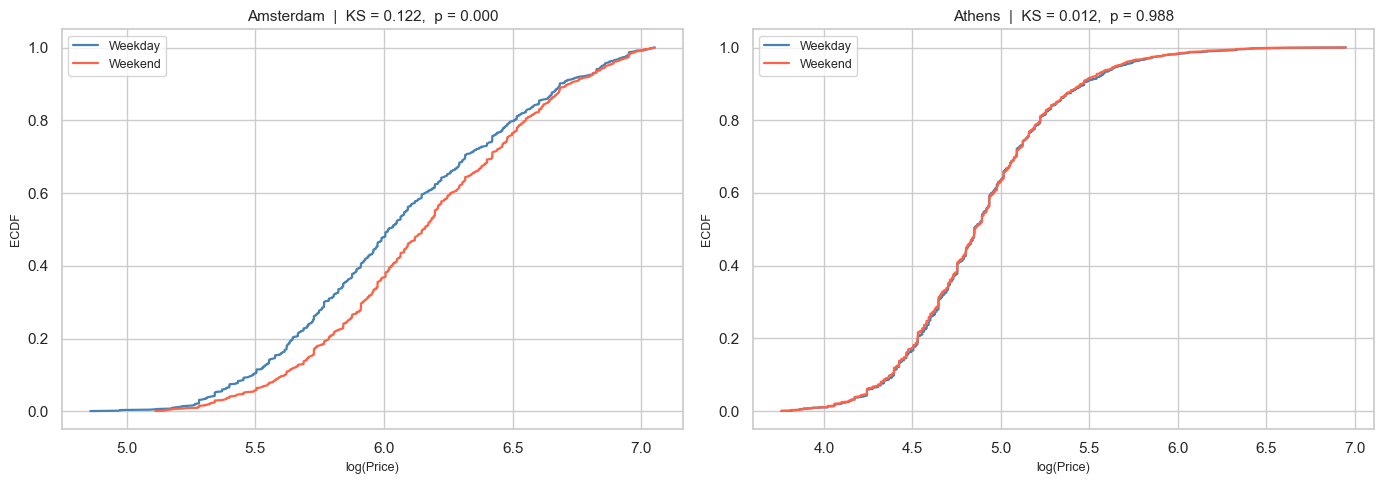

In [3]:
focus_cities = ["Amsterdam", "Athens"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city_name in zip(axes, focus_cities):
    city_df = df[df["city"] == city_name]
    weekday = city_df[city_df["is_weekday"] == 1]["logSum"].values
    weekend = city_df[city_df["is_weekday"] == 0]["logSum"].values

    ks_stat, p_value = stats.ks_2samp(weekday, weekend)

    for data, label, color in [
        (weekday, "Weekday", "steelblue"),
        (weekend, "Weekend", "tomato"),
    ]:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, ecdf, label=label, color=color, linewidth=1.6)

    ax.set_title(f"{city_name}  |  KS = {ks_stat:.3f},  p = {p_value:.3f}", fontsize=11)
    ax.set_xlabel("log(Price)", fontsize=9)
    ax.set_ylabel("ECDF", fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots_overleaf/section2_PlotHypothesis1_amsterdamAthensKS.png", dpi=300, bbox_inches="tight")
plt.show()


## 2.4 Pooled Weekday vs. Weekend K-S Test
Pool listings across all cities and test whether the overall weekday and weekend log-price distributions differ.

**Output.** Displays the pooled K-S statistic, p-value, sample sizes, and saves the pooled ECDF comparison plot.


,KS Stat,p-value,n weekday,n weekend
Comparison,,,,
All cities: Weekday vs Weekend,0.035,0.000,25262,25927


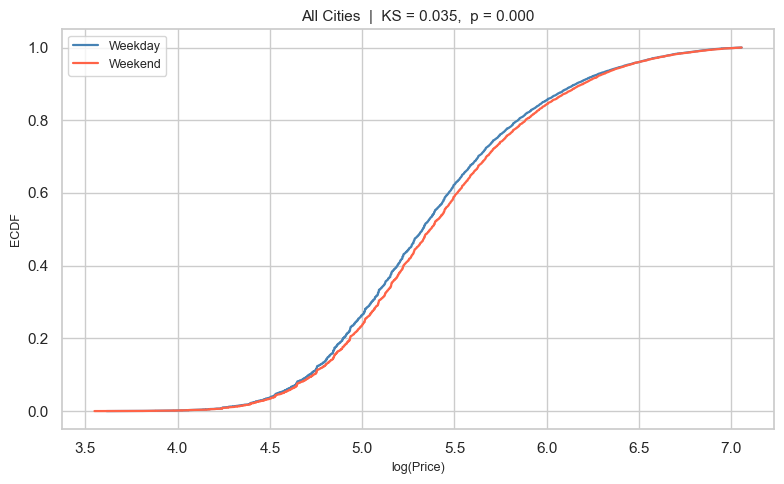

In [4]:
weekday_all = df[df["is_weekday"] == 1]["logSum"].values
weekend_all = df[df["is_weekday"] == 0]["logSum"].values

pooled_ks_stat, pooled_p_value = stats.ks_2samp(weekday_all, weekend_all)

pooled_ks_summary = pd.DataFrame([
    {
        "Comparison": "All cities: Weekday vs Weekend",
        "KS Stat": round(pooled_ks_stat, 3),
        "p-value": f"{pooled_p_value:.3f}",
        "n weekday": len(weekday_all),
        "n weekend": len(weekend_all),
    }
]).set_index("Comparison")

display(pooled_ks_summary)

fig, ax = plt.subplots(figsize=(8, 5))
for data, label, color in [
    (weekday_all, "Weekday", "steelblue"),
    (weekend_all, "Weekend", "tomato"),
]:
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, ecdf, label=label, color=color, linewidth=1.6)

ax.set_title(
    f"All Cities  |  KS = {pooled_ks_stat:.3f},  p = {pooled_p_value:.3f}",
    fontsize=11,
)
ax.set_xlabel("log(Price)", fontsize=9)
ax.set_ylabel("ECDF", fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots_overleaf/section2_PlotHypothesis1_pooledWeekdayWeekendKS.png", dpi=300, bbox_inches="tight")
plt.show()


## 2.5 Equality of Variances Across Cities
Apply Levene's test to determine whether log-price variance differs across cities.

**Output.** Displays the test result and saves a variance-by-city bar chart.


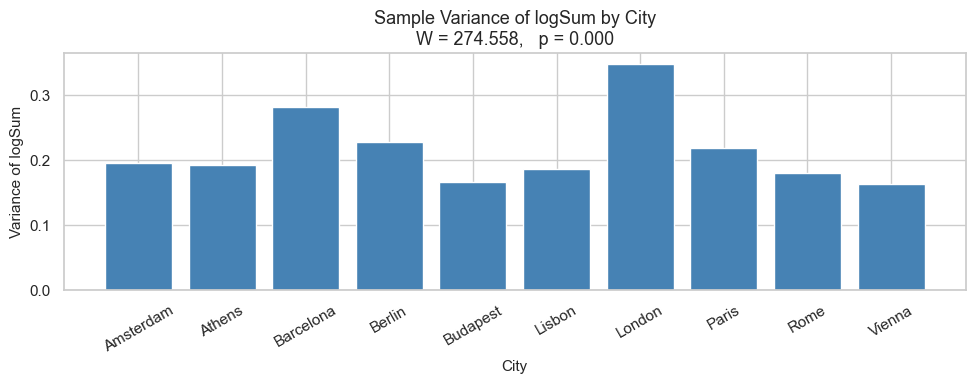

In [5]:
city_groups = [df[df['city'] == CITY_NAMES[cid]]['logSum'].values for cid in sorted(CITY_NAMES)]
lev_stat, lev_p = stats.levene(*city_groups)
sig = "Reject H0: variances differ significantly" if lev_p < 0.05 else "Fail to reject H0"

levene_summary = pd.DataFrame({
    'Test': ["Levene's Test"],
    'Outcome': ['Equality of variances across cities'],
    'W': [lev_stat],
    'p-value': [lev_p],
    'Conclusion': [sig],
}).round({'W': 3, 'p-value': 3})

# display(levene_summary)

# Per-city variance bar chart
city_vars = {
    CITY_NAMES[cid]: df[df['city'] == CITY_NAMES[cid]]['logSum'].var(ddof=1)
    for cid in sorted(CITY_NAMES)
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(city_vars.keys(), city_vars.values(), color='steelblue', edgecolor='white')
ax.set_title(
    f"Sample Variance of logSum by City\n"
    f"W = {lev_stat:.3f},   p = {lev_p:.3f}",
    fontsize=13
)
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Variance of logSum", fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('plots_overleaf/section2_PlotHypothesis2_cityVarianceLevene.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.6 Room-Type Independence Tests
Test whether room-type distributions differ by city and by weekday/weekend status using chi-square tests.

**Output.** Displays test summaries, contingency tables, and stacked proportion plots.


,Test,chi^2,df,p-value
0,Room Type x City,9287.475,18,0.000
1,Room Type x Weekday/Weekend,3.621,2,0.164


room_type_cat,Entire apt,Private room,Shared room
city,,,
Amsterdam,1001,933,10
Athens,4871,397,11
Barcelona,524,2276,12
Berlin,870,1527,73
Budapest,3583,419,14
Lisbon,3875,1811,74
London,4215,5528,50
Paris,4960,1517,94
Rome,5547,3451,12


room_type_cat,Entire apt,Private room,Shared room
is_weekday,,,
Weekday,15784,9298,180
Weekend,16408,9333,186


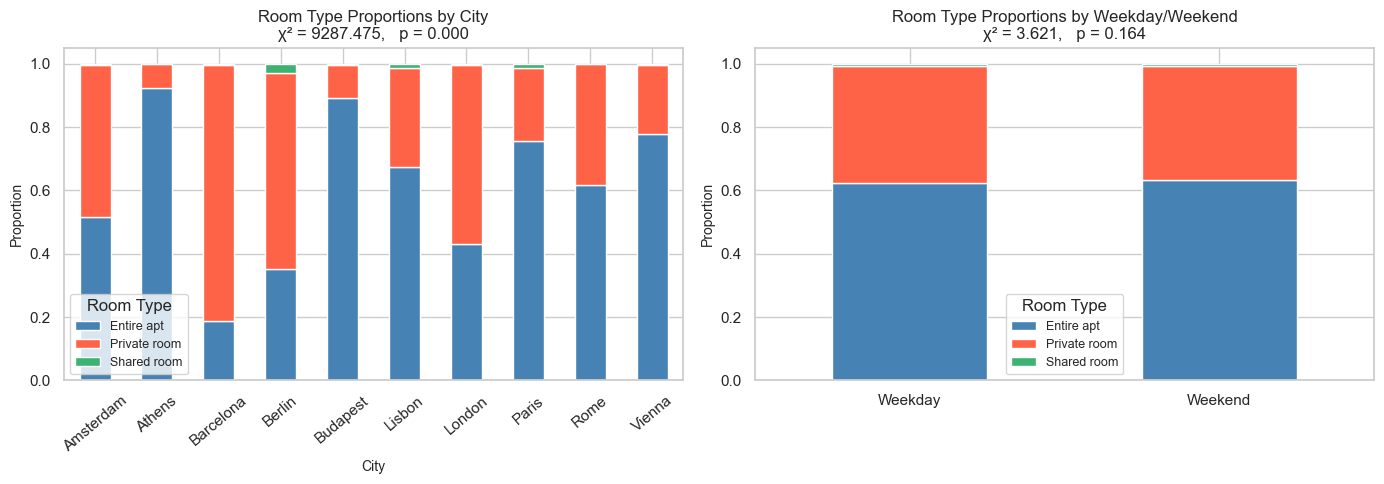

In [6]:

room_col_map = {
    'room_type_apt':     'Entire apt',
    'room_type_private': 'Private room',
    'room_type_shared':  'Shared room',
}
df['room_type_cat'] = (
    df[['room_type_apt', 'room_type_private', 'room_type_shared']]
    .idxmax(axis=1)
    .map(room_col_map)
)

ct_city = pd.crosstab(df['city'], df['room_type_cat'])
chi2_city, p_city, dof_city, _ = stats.chi2_contingency(ct_city)
sig_city = "Reject H0: room type distribution differs by city" if p_city < 0.05 else "Fail to reject H0"

ct_week = pd.crosstab(
    df['is_weekday'].map({1: 'Weekday', 0: 'Weekend'}),
    df['room_type_cat']
)
chi2_week, p_week, dof_week, _ = stats.chi2_contingency(ct_week)
sig_week = "Reject H0: room type distribution differs by period" if p_week < 0.05 else "Fail to reject H0"

chi_square_summary = pd.DataFrame({
    'Test': ['Room Type x City', 'Room Type x Weekday/Weekend'],
    'chi^2': [chi2_city, chi2_week],
    'df': [dof_city, dof_week],
    'p-value': [p_city, p_week],
}).round({'chi^2': 3, 'p-value': 3})

display(chi_square_summary)
display(ct_city)
display(ct_week)

room_colors = ['steelblue', 'tomato', 'mediumseagreen']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_city.div(ct_city.sum(axis=1), axis=0).plot(
    kind='bar', stacked=True, ax=axes[0],
    color=room_colors, edgecolor='white'
)
axes[0].set_title(
    f"Room Type Proportions by City\nχ² = {chi2_city:.3f},   p = {p_city:.3f}",
    fontsize=12
)
axes[0].set_xlabel("City", fontsize=10)
axes[0].set_ylabel("Proportion", fontsize=10)
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='Room Type', fontsize=9)

ct_week.div(ct_week.sum(axis=1), axis=0).plot(
    kind='bar', stacked=True, ax=axes[1],
    color=room_colors, edgecolor='white'
)
axes[1].set_title(
    f"Room Type Proportions by Weekday/Weekend\nχ² = {chi2_week:.3f},   p = {p_week:.3f}",
    fontsize=12
)
axes[1].set_xlabel("", fontsize=10)
axes[1].set_ylabel("Proportion", fontsize=10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Room Type', fontsize=9)

plt.tight_layout()
plt.savefig('plots_overleaf/section2_PlotHypothesis3_roomTypeChiSquare.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.7 Superhost Price Premium Test
Use Welch's t-test to compare mean log prices for superhost and non-superhost listings.

**Output.** Displays sample sizes, means, test statistics, effect size, and conclusion.


In [7]:
superhost     = df[df['is_superhost'] == 1]['logSum'].values
non_superhost = df[df['is_superhost'] == 0]['logSum'].values

t_stat, t_p = stats.ttest_ind(superhost, non_superhost, equal_var=False)  # Welch's t-test

mean_sh  = superhost.mean()
mean_nsh = non_superhost.mean()

pooled_std = np.sqrt(
    ((len(superhost) - 1) * superhost.std(ddof=1)**2 +
     (len(non_superhost) - 1) * non_superhost.std(ddof=1)**2) /
    (len(superhost) + len(non_superhost) - 2)
)
cohens_d = (mean_sh - mean_nsh) / pooled_std
sig_sh = "Reject H0: superhost listings command a significant premium" if t_p < 0.05 else "Fail to reject H0"

superhost_test_summary = pd.DataFrame({
    'Test': ["Welch's t-test"],
    'Comparison': ['Superhost vs. non-superhost log(price)'],
    'n superhost': [len(superhost)],
    'n non-superhost': [len(non_superhost)],
    'Mean superhost': [mean_sh],
    'Mean non-superhost': [mean_nsh],
    't': [t_stat],
    'p-value': [t_p],
    "Cohen's d": [cohens_d],
}).round({'Mean superhost': 3, 'Mean non-superhost': 3, 't': 3, 'p-value': 3, "Cohen's d": 3})

display(superhost_test_summary)


,Test,Comparison,n superhost,n non-superhost,Mean superhost,Mean non-superhost,t,p-value,Cohen's d
0,Welch's t-test,Superhost vs. non-superhost log(price),13130,38059,5.331,5.422,-16.685,0.0,-0.162


## 2.8 City Mean Price Differences
Use one-way ANOVA to test whether average log prices differ across cities.

**Output.** Displays the ANOVA statistic, p-value, eta-squared effect size, and conclusion.


In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

city_groups = [df[df['city'] == CITY_NAMES[cid]]['logSum'].values for cid in sorted(CITY_NAMES)]
f_stat, anova_p = stats.f_oneway(*city_groups)

# eta^2 = SS_between / SS_total.
grand_mean = df['logSum'].mean()
ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2 for g in city_groups
)
ss_total = sum(((g - grand_mean) ** 2).sum() for g in city_groups)
eta_sq = ss_between / ss_total
effect_size = 'large' if eta_sq >= 0.14 else 'medium' if eta_sq >= 0.06 else 'small'
sig_anova = "Reject H0: at least one city mean differs" if anova_p < 0.05 else "Fail to reject H0"

anova_summary = pd.DataFrame({
    'Test': ['One-way ANOVA'],
    'Outcome': ['log(price) across 10 cities'],
    'F': [f_stat],
    'p-value': [anova_p],
    'eta^2': [eta_sq],
    'Effect size': [effect_size],
}).round({'F': 3, 'p-value': 3, 'eta^2': 3})

display(anova_summary)


,Test,Outcome,F,p-value,eta^2,Effect size
0,One-way ANOVA,log(price) across 10 cities,2242.501,0.0,0.283,large


## 2.9 Pairwise City Comparisons
Run Tukey HSD post-hoc tests to identify which city pairs differ after the ANOVA result.

**Output.** Displays a compact summary and the full pairwise comparison table sorted by absolute mean difference.


In [9]:
tukey = pairwise_tukeyhsd(
    endog=df['logSum'],
    groups=df['city'],
    alpha=0.05
)

tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
).rename(columns={'group1': 'City A', 'group2': 'City B',
                   'meandiff': 'Mean Diff', 'p-adj': 'p-adj',
                   'lower': 'CI Lower', 'upper': 'CI Upper',
                   'reject': 'Reject H0'})

sig_pairs = tukey_df[tukey_df['Reject H0'] == True]
tukey_summary = pd.DataFrame({
    'Metric': ['Total city pairs', 'Significant pairs', 'Alpha'],
    'Value': [len(tukey_df), len(sig_pairs), 0.05],
})

display(tukey_summary)
display(
    tukey_df.assign(**{'abs(Mean Diff)': tukey_df['Mean Diff'].abs()})
            .sort_values('abs(Mean Diff)', ascending=False)
            .drop(columns='abs(Mean Diff)')
            .reset_index(drop=True)
)


,Metric,Value
0,Total city pairs,45.00
1,Significant pairs,43.00
2,Alpha,0.05


,City A,City B,Mean Diff,p-adj,CI Lower,CI Upper,Reject H0
0,Amsterdam,Athens,-1.2167,0.0000,-1.2565,-1.1768,True
1,Amsterdam,Budapest,-1.0474,0.0000,-1.0888,-1.0059,True
2,Athens,Paris,0.9018,0.0000,0.8741,0.9296,True
3,Amsterdam,Rome,-0.8925,0.0000,-0.9300,-0.8549,True
4,Amsterdam,Berlin,-0.7855,0.0000,-0.8310,-0.7399,True
5,Amsterdam,Vienna,-0.7542,0.0000,-0.7966,-0.7118,True
6,Budapest,Paris,0.7325,0.0000,0.7025,0.7626,True
7,Amsterdam,Lisbon,-0.7308,0.0000,-0.7702,-0.6914,True
8,Athens,London,0.7074,0.0000,0.6818,0.7330,True
9,Amsterdam,Barcelona,-0.6564,0.0000,-0.7007,-0.6121,True
